## Caso de estudio: vaciado de un tanque con regresión lineal para modelos potenciales
### Juan S. Hincapié - Carlos Duque-Daza

### Teoría para la regresión lineal de un modelo potencial

Asuma que tiene datos experimentales de dos cantidades $Q$ y $h$ las cuales se asume que se relacionan mediante el siguiente modelo de potencia,

$$
Q(h) = \delta\,h^{n}
$$

donde $\delta$ y $n$ son el coeficiente de proporcionalidad y la potencia del modelo, respectivamente.

Para poder determinar los valores de $\delta$ y $n$, dado un conjunto de valores de $Q$ y $h$, podemos hacer regresión lineal haciendo un pequeño ajuste del modelo.  Para tal fin se toman los logaritmos naturales (o cualquier otro logaritmo) de cada lado del modelo de potencia, con lo que se obtiene:

\begin{equation}
\begin{aligned}
Q &= \delta\,h^{n} \\
\log\left(Q\right) &= \log\left(\delta\,h^{n}\right)\\
Y &= \log{\delta} + \log{h^{n}}\\
Y &= \log{\delta} + n\,\log{h}\\
\end{aligned}
\end{equation}

lo que se puede expresar simplemente como:
$$
Y = n\,X + \log{\delta}
$$

o 
$$
Y = M X + B
$$

donde $Y = \log{(Q)}$, $M=n$, $X = \log{(h)}$, y $B=\log{(\delta)}$

De esta forma, encontrar el coeficiente $\delta$ y el exponente $n$, es simplemente un proceso de determinar la pendiente y el intersecto con el eje $Y$ en el espacio de los datos convertidos en forma logaritmica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Promedio y desviación estándar
mu, sigma = 0, 0.2 
# Números "aleatorios"
s = np.random.normal(mu, sigma, 200)
# Valores de altura 
hTest = np.linspace(0.05, 90, 200)
# Potencia del modelo
n = 0.5
# Coeficiente de proporcionalidad
delta = 1.89
# Ejecutamos el modelo potencial
QTest = delta * np.power(hTest,n) + s

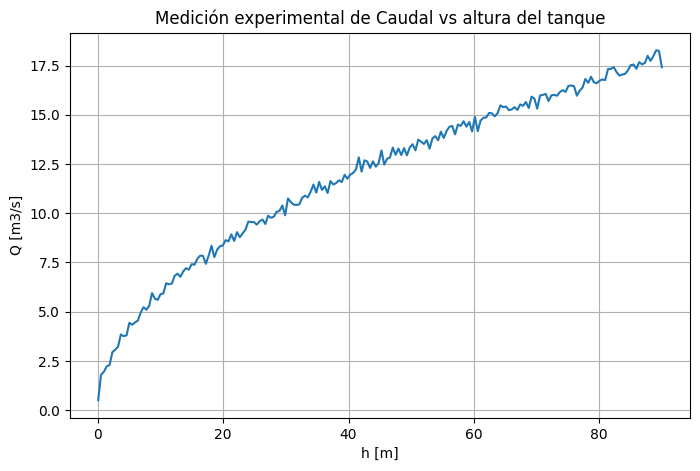

In [4]:
plt.figure(1, figsize=(8,5))
plt.plot(hTest,QTest)
plt.xlabel("h [m]")
plt.ylabel("Q [m3/s]")
plt.title("Medición experimental de Caudal vs altura del tanque")
plt.grid()

In [5]:
# Sacamos el logarítmo de Qtest y de hTest
Y = np.log(QTest)
X = np.log(hTest)

# Aplicando regresión lineal (revisar https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)
A = np.vstack([X, np.ones(len(X))]).T

# Aplicamos mínimos cuadrados
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(m,", ",c)
deltaLR = np.exp(c)
nLR = m
print("n=", nLR, ", delta = ", deltaLR)

0.49032520647746586 ,  0.670361869361739
n= 0.49032520647746586 , delta =  1.9549446272164166


In [6]:
Q = deltaLR * np.power(hTest,nLR)

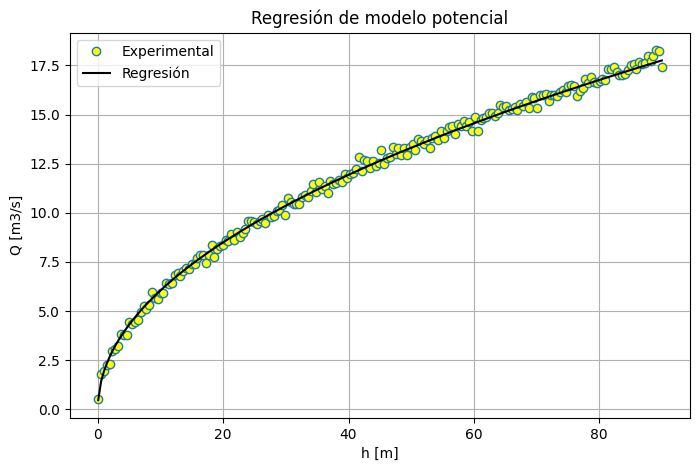

In [7]:
plt.figure(2, figsize=(8,5))
plt.plot(hTest,QTest,marker="o",label = "Experimental", linestyle="None",markerfacecolor="yellow")
plt.plot(hTest,Q,'-k', label = "Regresión", marker="None")
plt.xlabel("h [m]")
plt.ylabel("Q [m3/s]")
plt.title("Regresión de modelo potencial")
plt.grid()
plt.legend()
plt.show()